# Construction du dataset DPO

Objectif : construire le dataset DPO à partir d'UltraMedical-Preference, la seule source de paires de préférences du projet.

Chaque exemple est une paire : un prompt, une réponse préférée (`chosen`) et une réponse écartée (`rejected`). Le notebook traite quatre points :

- les doublons exacts ;
- le biais de longueur repéré au notebook 01 (la réponse préférée est souvent la plus longue) ;
- les paires dont la préférence ne s'appuie pas sur un meilleur score ;
- le découpage, qui est celui du notebook 03, commun au SFT et au DPO.

Ce notebook exécute et documente les fonctions de `scripts/extraction.py` et de `scripts/examples.py`.

In [1]:
import sys
import warnings
from collections import Counter

sys.path.append("..")
# tqdm signale qu'ipywidgets manque (barres de progression) : sans effet sur les calculs
warnings.filterwarnings("ignore", message="IProgress not found")

import matplotlib.pyplot as plt
import pandas as pd

from scripts.cases import find_leaks, split_cases
from scripts.examples import build_dpo_examples, keep_scored_preferences
from scripts.extraction import build_dpo_dataset, build_sft_dataset, clean_dpo_dataset, load_split_units
from src.visualizer import create_barplot, save_figure

SPLITS = ["train", "validation", "test"]
TYPES = ["hard", "length", "easy", "human"]

## Chargement

`load_split_units` charge tout ce qui entre dans le découpage par cas : les cas de triage annotés, les questions de QA et les paires UltraMedical-Preference. Je garde ici les paires, et le reste servira plus bas au découpage.

Deux exclusions sont déjà faites au chargement (notebook 02) : les questions de forum, qui contiennent de vrais noms de patients, et les paires où un nom est repéré.

In [2]:
unites = load_split_units()
brut = [r for r in unites if "prompt" in r]

print("paires chargées :", len(brut))
print("split d'origine :", dict(Counter(r["split"] for r in brut)))

UltraMedical-Preference test: 100%|██████████| 777/777 [00:00<00:00, 3862.67it/s]

paires chargées : 95426
split d'origine : {'train': 92948, 'validation': 1882, 'test': 596}


Le split d'origine n'est gardé que pour mémoire. La source met presque toutes ses paires dans le train, et certains prompts sont à la fois dans son train et dans sa validation. Le découpage par cas, plus bas, remplace ces splits et règle ce problème : un prompt va dans un seul split, avec toutes ses paires.

## Doublons exacts (prompt, chosen, rejected)

Un même prompt a normalement plusieurs paires chosen/rejected différentes, c'est le principe du dataset. Mais un triple identique répété plusieurs fois est un vrai doublon.

In [3]:
cles = [(r["prompt"], r["chosen"], r["rejected"]) for r in brut]
compteur = Counter(cles)
doublons = {cle: n for cle, n in compteur.items() if n > 1}

print("triples uniques en double :", len(doublons))
print("lignes en trop à retirer :", sum(n - 1 for n in doublons.values()))
print("prompts uniques :", len(set(r["prompt"] for r in brut)), "/", len(brut), "lignes")

triples uniques en double : 10646
lignes en trop à retirer : 10646
prompts uniques : 67468 / 95426 lignes


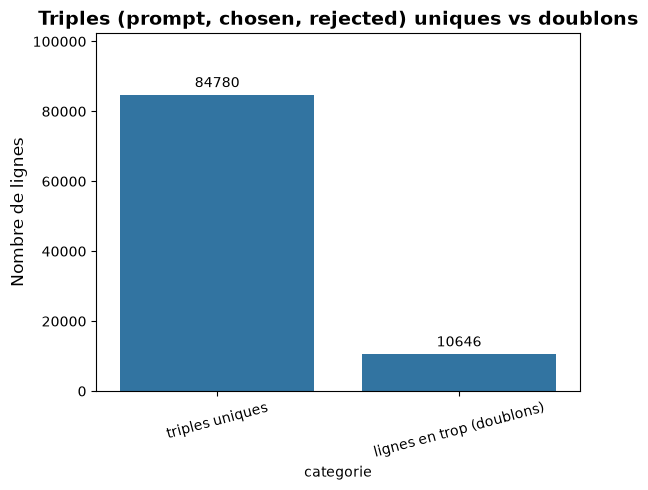

In [4]:
doublons_dpo_df = pd.DataFrame([
    {"categorie": "triples uniques", "n": len(compteur)},
    {"categorie": "lignes en trop (doublons)", "n": sum(n - 1 for n in doublons.values())},
])

fig, ax = plt.subplots(figsize=(6, 5))
create_barplot(
    doublons_dpo_df, ax, x="categorie", y="n",
    title="Triples (prompt, chosen, rejected) uniques vs doublons",
    xlabel="", ylabel="Nombre de lignes",
    fmt="{:.0f}", xrotation=15,
)
plt.tight_layout()
plt.show()

Un exemple de triple dupliqué, pour voir à quoi ça ressemble :

In [5]:
exemple = next(iter(doublons))
print("prompt  :", exemple[0][:200].replace("\n", " "), "...")
print("chosen  :", exemple[1][:150].replace("\n", " "), "...")
print("rejected:", exemple[2][:150].replace("\n", " "), "...")
print("répété", doublons[exemple], "fois")

prompt  : A lady comes with melanotic pigmentation of lip, presence of multiple polyps in the intestine, and a positive family history. What is the most probable diagnosis?  A. Peutz-Jegher's Syndrome B. Gardne ...
chosen  : Let's think step by step.  The patient has melanotic pigmentation of the lip, which is a characteristic feature of Peutz-Jeghers syndrome. Additionall ...
rejected: Let's break down the symptoms:  * Melanotic pigmentation of the lip: This is a common feature of several genetic syndromes. * Presence of multiple pol ...
répété 2 fois


Ce sont bien des lignes strictement identiques (même prompt, même réponse choisie, même réponse rejetée), pas des variantes utiles à garder. `clean_dpo_dataset` garde la première occurrence de chaque triple, comme pour le SFT.

In [6]:
paires = clean_dpo_dataset(brut)
print("paires chargées      :", len(brut))
print("après dédoublonnage  :", len(paires))
print("doublons retirés     :", len(brut) - len(paires))

paires chargées      : 95426
après dédoublonnage  : 84780
doublons retirés     : 10646


## Biais de longueur

Le notebook 01 a montré que la réponse préférée est plus longue que la réponse écartée dans 65 % des paires. Le risque est que le DPO apprenne au modèle à écrire long plutôt qu'à écrire juste.

La source indique comment chaque paire a été construite (`type_paire` : `hard`, `length`, `easy`, `human`) et donne une note sur 5 à chaque réponse (`score_chosen`, `score_rejected`). Je regarde le biais type par type.

In [7]:
def resume_par_type(records):
    """Pour chaque type de paire : longueur des réponses et comparaison des scores."""
    lignes = []
    for type_paire in TYPES + ["ensemble"]:
        groupe = [r for r in records if type_paire == "ensemble" or r["type_paire"] == type_paire]
        lignes.append({
            "type": type_paire,
            "paires": len(groupe),
            "chosen plus long (%)": round(100 * sum(len(r["chosen"]) > len(r["rejected"]) for r in groupe) / len(groupe)),
            "longueur médiane chosen": int(pd.Series([len(r["chosen"]) for r in groupe]).median()),
            "longueur médiane rejected": int(pd.Series([len(r["rejected"]) for r in groupe]).median()),
            "score pas meilleur (%)": round(100 * sum(r["score_chosen"] <= r["score_rejected"] for r in groupe) / len(groupe), 1),
        })
    return pd.DataFrame(lignes).set_index("type")


biais = resume_par_type(paires)
biais

,paires,chosen plus long (%),longueur médiane chosen,longueur médiane rejected,score pas meilleur (%)
type,,,,,
hard,34080,79,1901,1408,1.6
length,32928,37,1345,1474,15.8
easy,17646,89,1750,1119,0.0
human,126,70,1648,1324,19.8
ensemble,84780,65,1725,1363,6.8


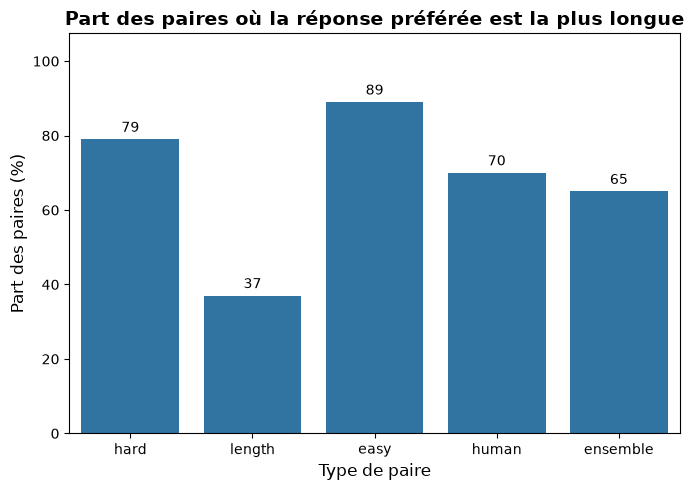

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
create_barplot(
    biais.reset_index(), ax, x="type", y="chosen plus long (%)",
    title="Part des paires où la réponse préférée est la plus longue",
    xlabel="Type de paire", ylabel="Part des paires (%)",
    xrotation=0, fmt="{:.0f}",
)
plt.tight_layout()
save_figure(fig, "05_construction_dpo/chosen_plus_long_par_type")
plt.show()

Le biais ne vient pas des paires `length`, contrairement à ce que leur nom laisse penser. Ce sont les seules où la réponse préférée est le plus souvent la plus courte : elles ont été construites pour montrer au modèle qu'une réponse plus longue n'est pas forcément meilleure. Les écarter aggraverait le biais au lieu de le réduire.

Le biais vient des paires `hard` et `easy`, où la réponse préférée est presque toujours la plus longue.

La dernière colonne montre un autre défaut : dans une partie des paires, surtout de type `length`, la réponse préférée n'a pas un meilleur score que la réponse écartée. La préférence ne s'y appuie sur rien de mesuré.

## Filtre sur les scores

`keep_scored_preferences` garde les paires où `score_chosen` est strictement supérieur à `score_rejected`. Les paires `length` sont gardées comme les autres, dès que leur réponse préférée a le meilleur score.

In [9]:
gardees = keep_scored_preferences(paires)
ecartees = Counter(r["type_paire"] for r in paires if r["score_chosen"] <= r["score_rejected"])

print("paires avant le filtre :", len(paires))
print("paires écartées        :", len(paires) - len(gardees), dict(ecartees))
print("paires gardées         :", len(gardees))

resume_par_type(gardees)

paires avant le filtre : 84780
paires écartées        : 5765 {'length': 5187, 'hard': 545, 'easy': 8, 'human': 25}
paires gardées         : 79015


,paires,chosen plus long (%),longueur médiane chosen,longueur médiane rejected,score pas meilleur (%)
type,,,,,
hard,33535,80,1906,1406,0.0
length,27741,33,1286,1473,0.0
easy,17638,89,1750,1119,0.0
human,101,70,1629,1222,0.0
ensemble,79015,65,1732,1353,0.0


Après le filtre, la dernière colonne est à zéro dans tous les types : chaque préférence gardée s'appuie sur un meilleur score.

Le biais de longueur reste, puisque le filtre ne porte pas sur la longueur. L'entraînement n'utilise qu'une partie des paires du train : le tirage de cette partie pourra l'équilibrer, avec autant de paires où la réponse préférée est la plus longue que de paires où elle est la plus courte.

## Découpage par cas

Le split de chaque paire est lu dans le découpage par cas du notebook 03, avec la clé de cas de son prompt. Les splits de la source ne sont pas repris.

Tous les prompts entrent dans le découpage, y compris ceux dont les paires viennent d'être écartées : le découpage ne dépend pas des filtres appliqués ensuite.

In [10]:
splits = split_cases(unites)
dpo = build_dpo_examples(gardees, splits)

dpo_df = pd.DataFrame([{"type": e["type_paire"], "split": e["split"]} for e in dpo])
tableau = pd.crosstab(dpo_df["type"], dpo_df["split"])[SPLITS].reindex(TYPES)
tableau["total"] = tableau.sum(axis=1)
tableau.loc["total"] = tableau.sum()

print("paires qui changent de split par rapport à la source :", sum("split_reassigne" in e["transformations"] for e in dpo))
tableau

paires qui changent de split par rapport à la source : 17087


split,train,validation,test,total
type,,,,
hard,26861,3342,3332,33535
length,22139,2775,2827,27741
easy,14067,1804,1767,17638
human,81,6,14,101
total,63148,7927,7940,79015


Les paires se répartissent à peu près en 80 % de train, 10 % de validation et 10 % de test. Le découpage se fait par prompt : les paires d'un même prompt restent ensemble, d'où de petits écarts par rapport à 80/10/10.

Chaque paire porte aussi `tache: "qa"`. Les prompts UltraMedical sont des questions médicales : à l'entraînement, ils reçoivent la même consigne que les exemples de QA du SFT, pour que le modèle voie le même format de prompt dans les deux phases.

## Contrôle de fuite

`find_leaks` est lancé sur le SFT et le DPO réunis. Deux cas de figure justifient de les contrôler ensemble :

- une vignette UltraMedical annotée pour le triage a aussi des paires de préférences. Si la vignette est dans le test de triage, ses paires ne doivent pas être dans le train du DPO ;
- certains prompts UltraMedical sont des copies de questions MedQuAD, qui servent au QA du SFT.

In [11]:
sft = build_sft_dataset()
fuites = find_leaks(sft + dpo)
print("clés de cas présentes dans plusieurs splits, SFT et DPO réunis :", len(fuites))

cles_test_triage = {e["cle_cas"] for e in sft if e["tache"] == "triage" and e["langue"] == "en" and e["split"] == "test"}
paires_du_test = [e for e in dpo if e["cle_cas"] in cles_test_triage]
print("vignettes anglaises dans le test de triage :", len(cles_test_triage))
print("paires DPO de ces vignettes :", len(paires_du_test), dict(Counter(e["split"] for e in paires_du_test)))

cles_medquad = {e["cle_cas"] for e in sft if e["source"] == "medquad"}
paires_medquad = [e for e in dpo if e["cle_cas"] in cles_medquad]
print("paires DPO dont le prompt est aussi une question MedQuAD du SFT :", len(paires_medquad))

UltraMedical-Preference test: 100%|██████████| 777/777 [00:00<00:00, 3117.23it/s]


clés de cas présentes dans plusieurs splits, SFT et DPO réunis : 0
vignettes anglaises dans le test de triage : 329
paires DPO de ces vignettes : 386 {'test': 386}
paires DPO dont le prompt est aussi une question MedQuAD du SFT : 176


Le premier compteur doit être à zéro. Les deux suivants montrent que le cas de figure existe : les paires des vignettes du test de triage sont toutes dans le test, et les prompts copiés de MedQuAD suivent le split de leur question.

## Vérification de `build_dpo_dataset`

`build_dpo_dataset` enchaîne toutes les étapes de ce notebook en un seul appel. C'est elle que le script d'export utilise. Je vérifie qu'elle donne les mêmes paires, dans les mêmes splits.

In [12]:
verification = build_dpo_dataset()
print("build_dpo_dataset() :", len(verification), "paires")
print("mêmes paires et mêmes splits :", [(e["id"], e["split"]) for e in verification] == [(e["id"], e["split"]) for e in dpo])

UltraMedical-Preference test: 100%|██████████| 777/777 [00:00<00:00, 3639.60it/s]


build_dpo_dataset() : 79015 paires
mêmes paires et mêmes splits : True


## Synthèse

Le dataset DPO vient d'UltraMedical-Preference (licence MIT, en anglais), sans les questions de forum ni les paires où un nom est repéré : 95 426 paires chargées. Trois traitements sont appliqués :

- les triples (prompt, chosen, rejected) en double sont retirés : 10 646 lignes, il reste 84 780 paires ;
- les paires où la réponse préférée n'a pas un score strictement meilleur sont écartées : 5 765 paires, dont 5 187 de type `length`. Il reste 79 015 paires ;
- le split vient du découpage par cas du notebook 03, commun au SFT et au DPO (environ 80 % train, 10 % validation, 10 % test). Aucune clé de cas n'est dans deux splits, les deux datasets réunis.

La réponse préférée est la plus longue dans 65 % des paires. Ce biais vient des paires `hard` (80 %) et `easy` (89 %). Les paires `length` vont dans l'autre sens (33 %) : elles sont gardées, ce sont elles qui limitent le biais.

Ce qui reste ouvert :

- le tirage des paires pour l'entraînement, qui pourra équilibrer les paires où la réponse préférée est la plus longue et celles où elle est la plus courte ;
- l'ajout de paires de triage (bon JSON contre cas sous trié ou JSON cassé), qui viserait directement les urgences ratées.